In [2]:
# ============================================================
#  Take-Home Test – Data Intern
#  Dataset : Advertising Performance (Jan 2025)
#  Clients : ABC, DEF, XYZ
# ============================================================

!pip install openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ── 1. LOAD DATA ────────────────────────────────────────────
FILE_PATH = "/content/Take-home Test - Data Intern.xlsx"

df = pd.read_excel(FILE_PATH, sheet_name="Raw")
print("Shape awal:", df.shape)
print(df.dtypes)
df.head()

Shape awal: (93, 7)
p_date         datetime64[ns]
Client Name            object
Cost (USD)             object
Clicks                  int64
Impressions             int64
Sales                   int64
GMV                    object
dtype: object


,p_date,Client Name,Cost (USD),Clicks,Impressions,Sales,GMV
0,2025-01-01,DEF,"$1,359",208730,3076808,15860,"$10,135"
1,2025-01-15,XYZ,"$1,928",5714,4203787,194,"$10,632"
2,2025-01-28,DEF,"$2,786",153481,10252866,11533,"$113,409"
3,2025-01-31,DEF,"$2,226",108236,9709253,7847,"$125,094"
4,2025-01-23,DEF,"$2,730",161019,11562560,11974,"$134,341"


In [5]:
# ── 2. CLEANING & TYPE CONVERSION ───────────────────────────

for col in ["Cost (USD)", "GMV"]:
    df[col] = df[col].str.replace(r"[\$,]", "", regex=True).astype(float)

In [6]:
df.rename(columns={
    "p_date"    : "date",
    "Client Name": "client",
    "Cost (USD)" : "cost",
    "Clicks"     : "clicks",
    "Impressions": "impressions",
    "Sales"      : "sales",
    "GMV"        : "gmv"
}, inplace=True)


df["date"] = pd.to_datetime(df["date"])

print("\n Setelah cleaning:")
print(df.dtypes)
print(df.head())


 Setelah cleaning:
date           datetime64[ns]
client                 object
cost                  float64
clicks                  int64
impressions             int64
sales                   int64
gmv                   float64
dtype: object
        date client    cost  clicks  impressions  sales       gmv
0 2025-01-01    DEF  1359.0  208730      3076808  15860   10135.0
1 2025-01-15    XYZ  1928.0    5714      4203787    194   10632.0
2 2025-01-28    DEF  2786.0  153481     10252866  11533  113409.0
3 2025-01-31    DEF  2226.0  108236      9709253   7847  125094.0
4 2025-01-23    DEF  2730.0  161019     11562560  11974  134341.0


In [7]:
# Mengubah format
df["date"] = pd.to_datetime(df["date"])

print("\n Setelah cleaning:")
print(df.dtypes)
print(df.head())



 Setelah cleaning:
date           datetime64[ns]
client                 object
cost                  float64
clicks                  int64
impressions             int64
sales                   int64
gmv                   float64
dtype: object
        date client    cost  clicks  impressions  sales       gmv
0 2025-01-01    DEF  1359.0  208730      3076808  15860   10135.0
1 2025-01-15    XYZ  1928.0    5714      4203787    194   10632.0
2 2025-01-28    DEF  2786.0  153481     10252866  11533  113409.0
3 2025-01-31    DEF  2226.0  108236      9709253   7847  125094.0
4 2025-01-23    DEF  2730.0  161019     11562560  11974  134341.0


In [8]:
# ── 3. FEATURE ENGINEERING (Derived Metrics) ────────────────

# CTR  = Clicks / Impressions  → seberapa sering iklan diklik
df["ctr"]  = df["clicks"] / df["impressions"]

# CVR  = Sales / Clicks        → seberapa sering klik → beli
df["cvr"]  = df["sales"] / df["clicks"]

# ROAS = GMV / Cost            → revenue per 1 USD dikeluarkan
df["roas"] = df["gmv"] / df["cost"]

# CPC  = Cost / Clicks         → biaya per klik
df["cpc"]  = df["cost"] / df["clicks"]

# CPO  = Cost / Sales          → biaya per order
df["cpo"]  = df["cost"] / df["sales"]

# AOV  = GMV / Sales           → rata-rata nilai per transaksi
df["aov"]  = df["gmv"] / df["sales"]

print("\n Derived metrics berhasil dibuat:")
print(df[["client","date","ctr","cvr","roas","cpc","cpo","aov"]].head())


 Derived metrics berhasil dibuat:
  client       date       ctr       cvr       roas       cpc       cpo  \
0    DEF 2025-01-01  0.067840  0.075983   7.457689  0.006511  0.085687   
1    XYZ 2025-01-15  0.001359  0.033952   5.514523  0.337417  9.938144   
2    DEF 2025-01-28  0.014970  0.075143  40.706748  0.018152  0.241568   
3    DEF 2025-01-31  0.011148  0.072499  56.196765  0.020566  0.283675   
4    DEF 2025-01-23  0.013926  0.074364  49.209158  0.016955  0.227994   

         aov  
0   0.639029  
1  54.804124  
2   9.833434  
3  15.941634  
4  11.219392  


In [9]:
# ── 4. AGGREGATE PER CLIENT ─────────────────────────────────

agg = df.groupby("client").agg(
    total_cost        = ("cost",        "sum"),
    total_clicks      = ("clicks",      "sum"),
    total_impressions = ("impressions",  "sum"),
    total_sales       = ("sales",       "sum"),
    total_gmv         = ("gmv",         "sum"),
).reset_index()

# derived metrics dari aggregated values
agg["ctr"]  = agg["total_clicks"]      / agg["total_impressions"]
agg["cvr"]  = agg["total_sales"]       / agg["total_clicks"]
agg["roas"] = agg["total_gmv"]         / agg["total_cost"]
agg["cpc"]  = agg["total_cost"]        / agg["total_clicks"]
agg["cpo"]  = agg["total_cost"]        / agg["total_sales"]
agg["aov"]  = agg["total_gmv"]         / agg["total_sales"]

print("\n Summary per client:")
print(agg.to_string(index=False))


 Summary per client:
client  total_cost  total_clicks  total_impressions  total_sales  total_gmv      ctr      cvr      roas      cpc       cpo        aov
   ABC    295098.0      11184515          370103543       574221 21623886.0 0.030220 0.051341 73.276966 0.026385  0.513910  37.657776
   DEF     72390.0       4263033          248119041       314554  2541305.0 0.017181 0.073786 35.105747 0.016981  0.230135   8.079074
   XYZ    136604.0        488830          175939652         8431  1675219.0 0.002778 0.017247 12.263323 0.279451 16.202586 198.697545


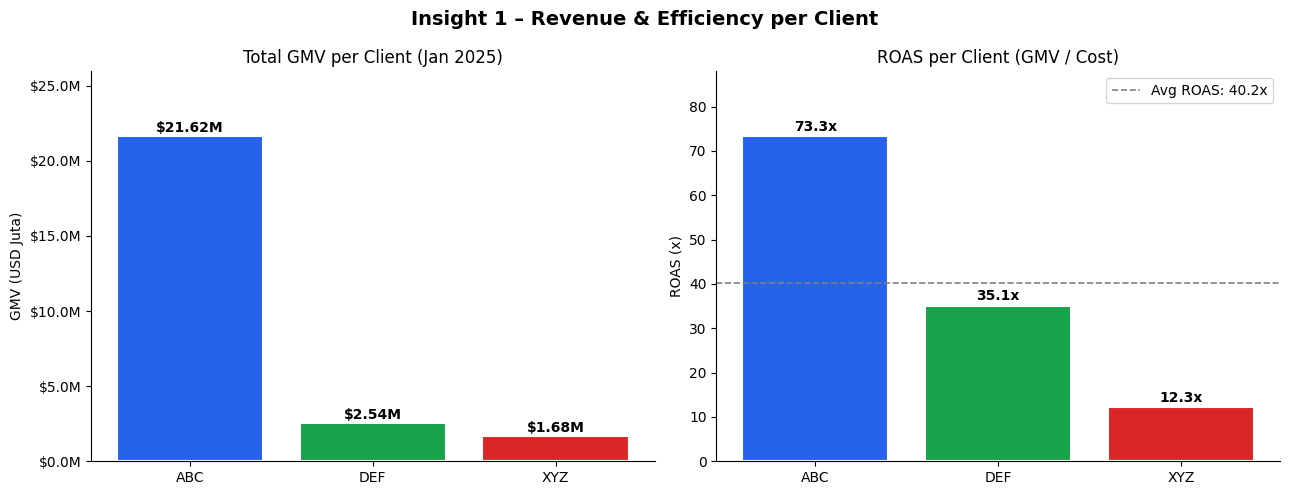

 Insight 1 tersimpan.


In [10]:
# ── 5. INSIGHT 1 – GMV & ROAS per Client ────────────────────
# Insight: ABC mendominasi GMV tapi bagaimana efisiensinya?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Insight 1 – Revenue & Efficiency per Client", fontsize=14, fontweight="bold")

colors = {"ABC": "#2563EB", "DEF": "#16A34A", "XYZ": "#DC2626"}
client_colors = [colors[c] for c in agg["client"]]

# Chart 1a: Total GMV
ax1 = axes[0]
bars = ax1.bar(agg["client"], agg["total_gmv"] / 1e6, color=client_colors, edgecolor="white", linewidth=1.5)
ax1.set_title("Total GMV per Client (Jan 2025)", fontsize=12)
ax1.set_ylabel("GMV (USD Juta)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
for bar, val in zip(bars, agg["total_gmv"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"${val/1e6:.2f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_ylim(0, agg["total_gmv"].max()/1e6 * 1.2)
ax1.spines[["top","right"]].set_visible(False)

# Chart 1b: ROAS
ax2 = axes[1]
bars2 = ax2.bar(agg["client"], agg["roas"], color=client_colors, edgecolor="white", linewidth=1.5)
ax2.axhline(y=agg["roas"].mean(), color="gray", linestyle="--", linewidth=1.2, label=f"Avg ROAS: {agg['roas'].mean():.1f}x")
ax2.set_title("ROAS per Client (GMV / Cost)", fontsize=12)
ax2.set_ylabel("ROAS (x)")
ax2.legend()
for bar, val in zip(bars2, agg["roas"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}x", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylim(0, agg["roas"].max() * 1.2)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("insight1_gmv_roas.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Insight 1 tersimpan.")


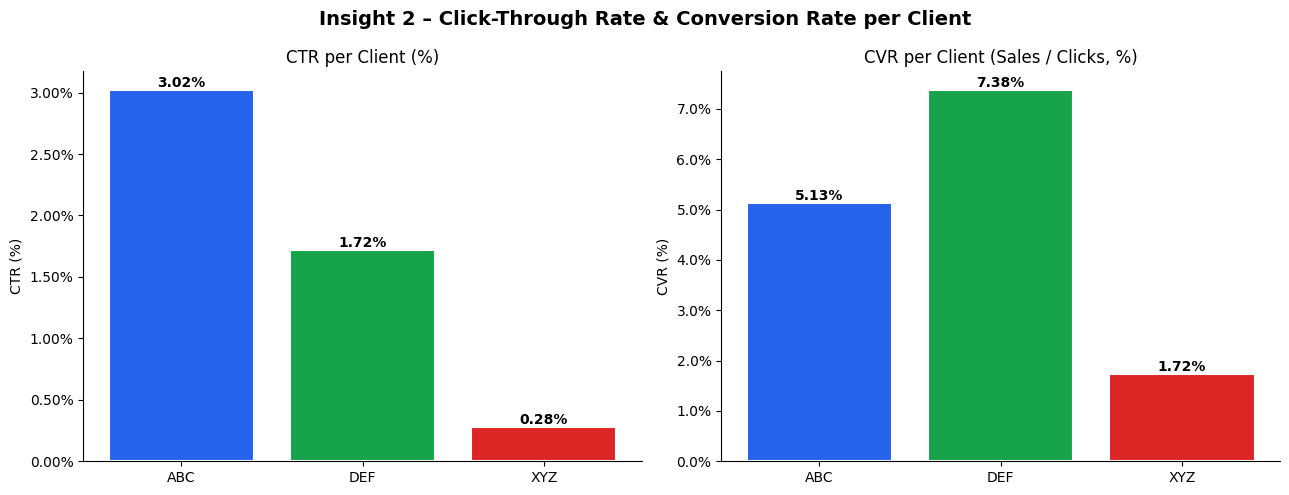

 Insight 2 tersimpan.


In [11]:
# ── 6. INSIGHT 2 – CTR & CVR per Client ─────────────────────
# Insight: Siapa yang efisien dalam mengkonversi impression → klik → beli?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Insight 2 – Click-Through Rate & Conversion Rate per Client", fontsize=14, fontweight="bold")

# Chart 2a: CTR
ax1 = axes[0]
bars = ax1.bar(agg["client"], agg["ctr"] * 100, color=client_colors, edgecolor="white", linewidth=1.5)
ax1.set_title("CTR per Client (%)", fontsize=12)
ax1.set_ylabel("CTR (%)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}%"))
for bar, val in zip(bars, agg["ctr"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val*100:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.spines[["top","right"]].set_visible(False)

# Chart 2b: CVR
ax2 = axes[1]
bars2 = ax2.bar(agg["client"], agg["cvr"] * 100, color=client_colors, edgecolor="white", linewidth=1.5)
ax2.set_title("CVR per Client (Sales / Clicks, %)", fontsize=12)
ax2.set_ylabel("CVR (%)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
for bar, val in zip(bars2, agg["cvr"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val*100:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("insight2_ctr_cvr.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Insight 2 tersimpan.")

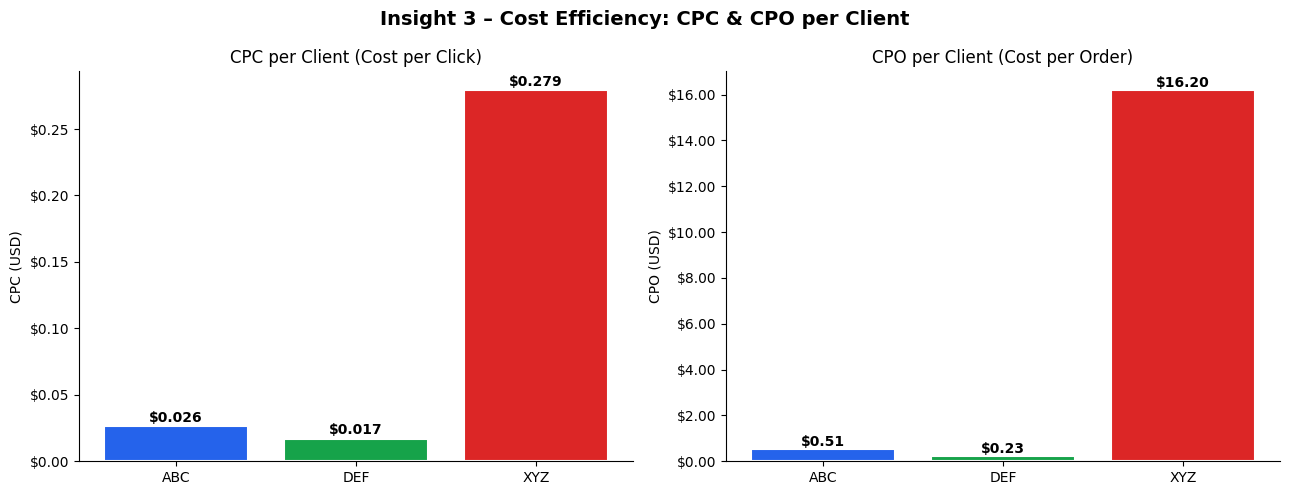

 Insight 3 tersimpan.


In [12]:
# ── 7. INSIGHT 3 – Cost Efficiency: CPC & CPO ───────────────
# Insight: Siapa yang paling mahal untuk dapat 1 klik / 1 order?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Insight 3 – Cost Efficiency: CPC & CPO per Client", fontsize=14, fontweight="bold")

# Chart 3a: CPC
ax1 = axes[0]
bars = ax1.bar(agg["client"], agg["cpc"], color=client_colors, edgecolor="white", linewidth=1.5)
ax1.set_title("CPC per Client (Cost per Click)", fontsize=12)
ax1.set_ylabel("CPC (USD)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))
for bar, val in zip(bars, agg["cpc"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"${val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.spines[["top","right"]].set_visible(False)

# Chart 3b: CPO
ax2 = axes[1]
bars2 = ax2.bar(agg["client"], agg["cpo"], color=client_colors, edgecolor="white", linewidth=1.5)
ax2.set_title("CPO per Client (Cost per Order)", fontsize=12)
ax2.set_ylabel("CPO (USD)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))
for bar, val in zip(bars2, agg["cpo"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"${val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("insight3_cpc_cpo.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Insight 3 tersimpan.")


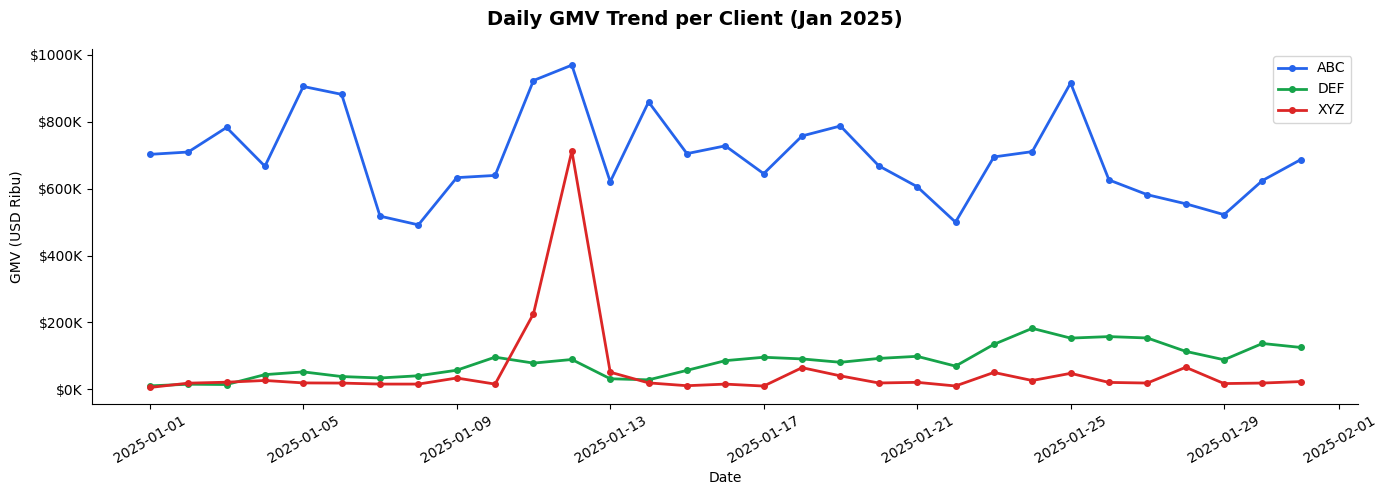

 Trend harian tersimpan.


In [13]:
# ── 8. TREND GMV HARIAN PER CLIENT ──────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Daily GMV Trend per Client (Jan 2025)", fontsize=14, fontweight="bold")

for client, color in colors.items():
    subset = df[df["client"] == client].sort_values("date")
    ax.plot(subset["date"], subset["gmv"] / 1e3, marker="o", markersize=4,
            label=client, color=color, linewidth=2)

ax.set_ylabel("GMV (USD Ribu)")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("trend_gmv_harian.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Trend harian tersimpan.")


In [16]:

# File 1
df.to_csv("advertising_detail.csv", index=False)

# File 2
agg.to_csv("advertising_summary.csv", index=False)

print("   1. advertising_detail.csv  → untuk time-series & drill-down")
print("   2. advertising_summary.csv → untuk summary cards & bar charts")

   1. advertising_detail.csv  → untuk time-series & drill-down
   2. advertising_summary.csv → untuk summary cards & bar charts


In [14]:
print(df[['cost', 'gmv']].head())
print("Total GMV:", df['gmv'].sum())   # harus 25,840,410
print("Total Cost:", df['cost'].sum()) # harus 504,092

     cost       gmv
0  1359.0   10135.0
1  1928.0   10632.0
2  2786.0  113409.0
3  2226.0  125094.0
4  2730.0  134341.0
Total GMV: 25840410.0
Total Cost: 504092.0


In [15]:
df.to_csv("advertising_detail.csv", index=False)